In [7]:
# Importando bibliotecas necessárias
import yfinance as yf
import numpy as np
import pandas as pd
import datetime as dt

# Definindo o período de análise
inicio = dt.date(2015, 1, 1)
final = dt.date(2025, 1, 1)

# Lista de ações (exemplo com empresas americanas)
lista_acoes = ["AAPL", "NKE", "GOOGL", "AMZN"]

# Baixando os preços ajustados das ações no período especificado
precos = yf.download(lista_acoes, inicio, final, progress=False)["Close"]  # Usando "Close" em vez de "Adj Close"

# Limitando o número de linhas exibidas no terminal
pd.set_option('display.max_rows', 10)  # Mostra apenas 10 linhas

# Exibindo os preços de forma organizada
print("Preços das Ações:")
print(precos.round(2))  # Arredonda os valores para 2 casas decimais




Preços das Ações:
Ticker        AAPL    AMZN   GOOGL    NKE
Date                                     
2015-01-02   24.32   15.43   26.35  42.14
2015-01-05   23.64   15.11   25.85  41.46
2015-01-06   23.64   14.76   25.21  41.22
2015-01-07   23.97   14.92   25.14  42.07
2015-01-08   24.89   15.02   25.22  43.04
...            ...     ...     ...    ...
2024-12-24  257.92  229.05  195.88  76.40
2024-12-26  258.74  227.05  195.38  76.55
2024-12-27  255.31  223.75  192.54  76.04
2024-12-30  251.92  221.30  191.02  74.27
2024-12-31  250.14  219.39  189.08  75.29

[2516 rows x 4 columns]


In [9]:
# Calculando os retornos logarítmicos
retornos = precos.pct_change().apply(lambda x: np.log(1 + x)).dropna()  # Retorno logarítmico

# Calculando a média dos retornos e a matriz de covariância
media_retornos = retornos.mean()
matriz_cov = retornos.cov()
media_retornos

,0
Ticker,
AAPL,0.000927
AMZN,0.001056
GOOGL,0.000784
NKE,0.000231


In [10]:
matriz_cov

Ticker,AAPL,AMZN,GOOGL,NKE
Ticker,,,,
AAPL,0.000322,0.000205,0.000195,0.000151
AMZN,0.000205,0.000423,0.000239,0.000147
GOOGL,0.000195,0.000239,0.000321,0.000144
NKE,0.000151,0.000147,0.000144,0.000353


In [11]:
# Número de carteiras a serem geradas
numero_carteiras = 100000

# Inicialização das tabelas para armazenar os resultados
tabela_retornos_esperados = np.zeros(numero_carteiras)
tabela_volatilidades_esperadas = np.zeros(numero_carteiras)
tabela_sharpe = np.zeros(numero_carteiras)
tabela_pesos = np.zeros((numero_carteiras, len(lista_acoes)))

# Loop para gerar carteiras aleatórias
for k in range(numero_carteiras):
    # Geração de pesos aleatórios para as ações
    pesos = np.random.random(len(lista_acoes))
    pesos = pesos / np.sum(pesos)  # Só pode ter 100%

    # Armazenamento dos pesos na tabela
    tabela_pesos[k, :] = pesos

    # Cálculo do retorno esperado da carteira
    tabela_retornos_esperados[k] = np.sum(media_retornos * pesos) * 252

    # Cálculo da volatilidade esperada da carteira
    tabela_volatilidades_esperadas[k] = np.sqrt(np.dot(pesos.T, np.dot(matriz_cov * 252, pesos)))

    # Cálculo do Índice de Sharpe da carteira
    tabela_sharpe[k] = tabela_retornos_esperados[k] / tabela_volatilidades_esperadas[k]

In [16]:
tabela_sharpe

array([0.79847846, 0.8041842 , 0.90750031, ..., 0.78819021, 0.72176684,
       0.81523717])

In [17]:
tabela_retornos_esperados_arit = (1 + tabela_retornos_esperados) ** (1/252) - 1
tabela_retornos_esperados_arit

array([0.00074118, 0.00071356, 0.00087554, ..., 0.00068102, 0.00062821,
       0.00075148])

In [21]:
# Eixo y para a Fronteira Eficiente
eixo_y_fronteira_eficiente = np.linspace(tabela_retornos_esperados_arit.min(),
                                         tabela_retornos_esperados_arit.max(),
                                         50)

def pegando_retorno(peso_teste):
    peso_teste = np.array(peso_teste)
    retorno = np.sum(media_retornos * peso_teste) * 252
    retorno = np.exp(retorno) - 1
    return retorno

def checando_soma_pesos(peso_teste):
    return np.sum(peso_teste) - 1

def pegando_vol(peso_teste):
    peso_teste = np.array(peso_teste)
    vol = np.sqrt(np.dot(peso_teste.T, np.dot(matriz_cov * 252, peso_teste)))
    return vol

peso_inicial = [1 / len(lista_acoes)] * len(lista_acoes)


limites = tuple([(0, 1) for ativo in lista_acoes])

eixo_x_fronteira_eficiente = []


for retorno_possivel in eixo_y_fronteira_eficiente:

     #Vamos pegar a melhor volatilidade para cada retorno possivel


    restricoes = ({'type': 'eq', 'fun': checando_soma_pesos},
                  {'type': 'eq', 'fun': lambda w: pegando_retorno(w) - retorno_possivel})


    result = minimize(pegando_vol, peso_inicial, method='SLSQP', bounds=limites,
                      constraints=restricoes)
    eixo_x_fronteira_eficiente.append(result['fun'])


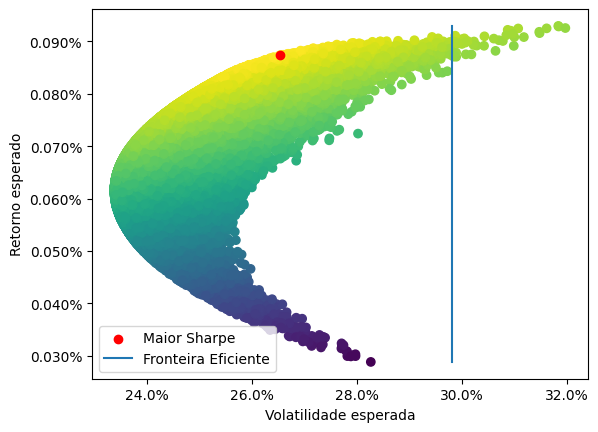

In [23]:
# Calculando o índice da carteira com o maior Índice de Sharpe
indice_do_sharpe_maximo = np.argmax(tabela_sharpe)

# Criando o gráfico
fig, ax = plt.subplots()

# Plotando os pontos das carteiras aleatórias
ax.scatter(tabela_volatilidades_esperadas, tabela_retornos_esperados_arit, c=tabela_sharpe)
plt.xlabel("Volatilidade esperada")
plt.ylabel("Retorno esperado")

# Destacando a carteira com o maior Índice de Sharpe
ax.scatter(tabela_volatilidades_esperadas[indice_do_sharpe_maximo],
           tabela_retornos_esperados_arit[indice_do_sharpe_maximo], c="red", label="Maior Sharpe")

# Plotando a Fronteira Eficiente
ax.plot(eixo_x_fronteira_eficiente, eixo_y_fronteira_eficiente, label="Fronteira Eficiente")

# Formatando os eixos para exibir porcentagens
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Adicionando legenda
ax.legend()

# Exibindo o gráfico
plt.show()


## 📈 Análise dos Resultados

O gráfico acima apresenta os principais conceitos da Teoria Moderna do Portfólio aplicada às ações da Apple (AAPL), Nike (NKE), Google (GOOGL) e Amazon (AMZN), com base nos dados entre 2015 e 2025.

### ✅ Pontos principais:

- **Pontos coloridos**: representam carteiras simuladas com diferentes pesos entre os ativos. Cada ponto mostra uma combinação possível de risco (volatilidade) e retorno.
- **Cor dos pontos**: representa o **Índice de Sharpe** de cada carteira. Quanto mais clara a cor, maior o índice, ou seja, melhor a relação retorno/risco.
- **Ponto vermelho**: marca a carteira com o **maior Índice de Sharpe** dentre todas simuladas, sendo a carteira mais eficiente em termos de retorno ajustado ao risco.
- **Linha azul (Fronteira Eficiente)**: mostra o conjunto de carteiras que oferecem o **melhor retorno possível para um dado nível de risco**. Essas carteiras são consideradas as mais eficientes do ponto de vista de Markowitz.

### 🧠 Conclusão:

A simulação e o gráfico mostram que a diversificação entre os ativos pode resultar em carteiras com melhor desempenho e menor risco do que investir em apenas um único ativo. A identificação da Fronteira Eficiente e da carteira com o maior Índice de Sharpe permite ao investidor tomar decisões mais estratégicas e racionais, baseadas em dados e otimização matemática.

> **Nota**: todos os cálculos assumem retorno logarítmico diário e consideram 252 dias úteis por ano.
